# Fund Performance Analytics

## Capstone Project I - Mutual Fund Analytics

Analysis of 40 mutual fund schemes including:
- Daily Returns
- CAGR
- Sharpe Ratio
- Sortino Ratio
- Alpha & Beta
- Maximum Drawdown
- Fund Scorecard
- Benchmark Comparison
- Tracking Error

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress


In [3]:
# Load datasets
fund_master = pd.read_csv("01_fund_master.csv")
nav_history = pd.read_csv("02_nav_history.csv")
benchmark = pd.read_csv("10_benchmark_indices.csv")

print("Fund Master:")
display(fund_master.head())

print("\nNAV History:")
display(nav_history.head())

print("\nBenchmark:")
display(benchmark.head())

Fund Master:


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02



NAV History:


,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692



Benchmark:


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [4]:
print("Fund Master columns:")
print(fund_master.columns.tolist())

print("\nNAV History columns:")
print(nav_history.columns.tolist())

print("\nBenchmark columns:")
print(benchmark.columns.tolist())

Fund Master columns:
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']

NAV History columns:
['amfi_code', 'date', 'nav']

Benchmark columns:
['date', 'index_name', 'close_value']


In [5]:
# Check the size of the NAV dataset
print("Rows:", nav_history.shape[0])
print("Columns:", nav_history.shape[1])

# Check data types and missing values
nav_history.info()

print("\nMissing values:")
print(nav_history.isnull().sum())

Rows: 46000
Columns: 3
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  object 
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ MB

Missing values:
amfi_code    0
date         0
nav          0
dtype: int64


In [8]:
# Check number of unique funds
print("Number of unique funds:", nav_history["amfi_code"].nunique())

# Show the first few fund codes
print(nav_history["amfi_code"].unique()[:20])

Number of unique funds: 40
[119551 119552 119598 119599 119120 100016 125497 100033 125498 100025
 120503 120504 120505 120506 120507 118632 118633 118634 118635 118636]


In [9]:
# Convert date column to datetime
nav_history["date"] = pd.to_datetime(nav_history["date"])

print("Start date:", nav_history["date"].min())
print("End date:", nav_history["date"].max())

Start date: 2022-01-03 00:00:00
End date: 2026-05-29 00:00:00


In [10]:
# Basic NAV checks
print(nav_history["nav"].describe())

print("\nMissing values:")
print(nav_history.isnull().sum())

count    46000.000000
mean       269.570265
std        577.187060
min         26.136600
25%         69.170425
50%        122.732150
75%        260.338675
max       4268.549700
Name: nav, dtype: float64

Missing values:
amfi_code    0
date         0
nav          0
dtype: int64


In [12]:
# Sort data by fund and date
nav_history = nav_history.sort_values(
    ["amfi_code", "date"]
).reset_index(drop=True)

# Calculate daily returns for each fund
nav_history["daily_return"] = (
    nav_history.groupby("amfi_code")["nav"].pct_change()
)

# Check the result
display(
    nav_history[
        ["amfi_code", "date", "nav", "daily_return"]
    ].head(20)
)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [13]:
# Summary statistics of daily returns
print(nav_history["daily_return"].describe())

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


In [14]:
# Check for extreme daily returns
print("Returns below -20%:",
      (nav_history["daily_return"] < -0.20).sum())

print("Returns above +20%:",
      (nav_history["daily_return"] > 0.20).sum())

Returns below -20%: 0
Returns above +20%: 0


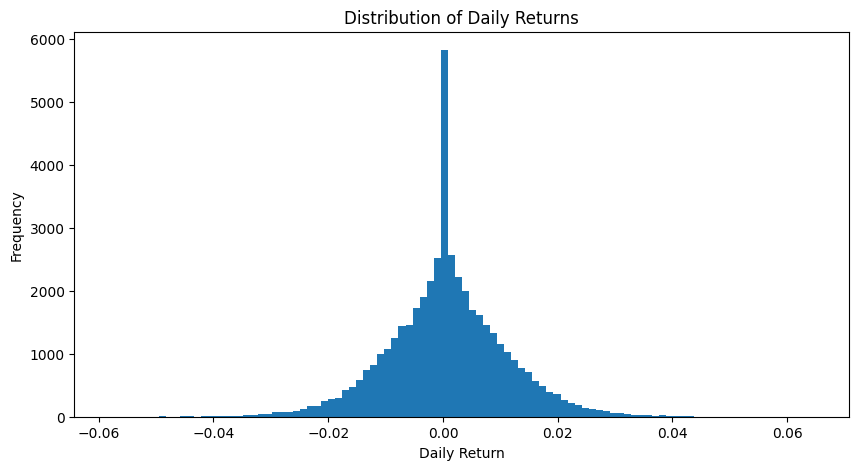

In [15]:
plt.figure(figsize=(10, 5))

plt.hist(
    nav_history["daily_return"].dropna(),
    bins=100
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [16]:
# Check the date range of each fund
fund_date_range = nav_history.groupby("amfi_code")["date"].agg(
    ["min", "max"]
)

fund_date_range["years"] = (
    fund_date_range["max"] - fund_date_range["min"]
).dt.days / 365.25

display(fund_date_range)

,min,max,years
amfi_code,,,
100016,2022-01-03,2026-05-29,4.399726
100025,2022-01-03,2026-05-29,4.399726
100033,2022-01-03,2026-05-29,4.399726
101206,2022-01-03,2026-05-29,4.399726
101207,2022-01-03,2026-05-29,4.399726
101208,2022-01-03,2026-05-29,4.399726
102885,2022-01-03,2026-05-29,4.399726
102886,2022-01-03,2026-05-29,4.399726
102887,2022-01-03,2026-05-29,4.399726


In [17]:
# Check how many funds have at least 1, 3 and 5 years of data
print("Funds with >= 1 year:",
      (fund_date_range["years"] >= 1).sum())

print("Funds with >= 3 years:",
      (fund_date_range["years"] >= 3).sum())

print("Funds with >= 5 years:",
      (fund_date_range["years"] >= 5).sum())

Funds with >= 1 year: 40
Funds with >= 3 years: 40
Funds with >= 5 years: 0


## Data Limitation — 5-Year CAGR

The available NAV history contains at least 3 years of observations
for all 40 schemes, but does not contain 5 years of historical data.

Therefore:
- 1-year CAGR is calculated for all 40 schemes.
- 3-year CAGR is calculated for all 40 schemes.
- 5-year CAGR cannot be reliably calculated from the available dataset
  and is reported as unavailable rather than estimated.
  

In [18]:
def calculate_cagr(nav_data, years):
    results = []

    for fund, data in nav_data.groupby("amfi_code"):
        data = data.sort_values("date")

        end_date = data["date"].max()
        start_target = end_date - pd.DateOffset(years=years)

        # Find the NAV closest to the target date
        start_data = data[data["date"] >= start_target]

        if start_data.empty:
            results.append({
                "amfi_code": fund,
                f"CAGR_{years}Y": np.nan
            })
            continue

        start_row = start_data.iloc[0]
        end_row = data.iloc[-1]

        actual_years = (
            (end_row["date"] - start_row["date"]).days / 365.25
        )

        cagr = (
            (end_row["nav"] / start_row["nav"])
            ** (1 / actual_years)
        ) - 1

        results.append({
            "amfi_code": fund,
            f"CAGR_{years}Y": cagr
        })

    return pd.DataFrame(results)

In [19]:
cagr_1y = calculate_cagr(nav_history, 1)
cagr_3y = calculate_cagr(nav_history, 3)

In [20]:
cagr_table = cagr_1y.merge(
    cagr_3y,
    on="amfi_code",
    how="outer"
)

cagr_table["CAGR_5Y"] = np.nan

display(cagr_table.head(10))

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-0.022258,0.012924,NaN
1,100025,0.037076,0.039155,NaN
2,100033,0.532772,0.324340,NaN
3,101206,0.479638,0.289602,NaN
4,101207,-0.240003,-0.041515,NaN
5,101208,0.072418,0.063143,NaN
6,102885,0.202229,0.196624,NaN
7,102886,-0.168080,-0.007672,NaN
8,102887,0.135930,0.255497,NaN
9,118632,0.340079,0.226466,NaN


In [21]:
cagr_display = cagr_table.copy()

for col in ["CAGR_1Y", "CAGR_3Y", "CAGR_5Y"]:
    cagr_display[col] = cagr_display[col] * 100

cagr_display = cagr_display.round(2)

display(cagr_display)

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-2.23,1.29,NaN
1,100025,3.71,3.92,NaN
2,100033,53.28,32.43,NaN
3,101206,47.96,28.96,NaN
4,101207,-24.00,-4.15,NaN
5,101208,7.24,6.31,NaN
6,102885,20.22,19.66,NaN
7,102886,-16.81,-0.77,NaN
8,102887,13.59,25.55,NaN
9,118632,34.01,22.65,NaN


In [22]:
# Annual risk-free rate
rf_annual = 0.065

# Convert annual risk-free rate to daily
rf_daily = (1 + rf_annual) ** (1 / 252) - 1

print("Annual risk-free rate:", rf_annual)
print("Daily risk-free rate:", rf_daily)

Annual risk-free rate: 0.065
Daily risk-free rate: 0.00024993122427763304


In [23]:
# Calculate Sharpe Ratio for each fund

sharpe_results = []

for fund, data in nav_history.groupby("amfi_code"):

    returns = data["daily_return"].dropna()

    excess_returns = returns - rf_daily

    sharpe = (
        excess_returns.mean()
        / returns.std()
    ) * np.sqrt(252)

    sharpe_results.append({
        "amfi_code": fund,
        "Sharpe_Ratio": sharpe
    })

sharpe_table = pd.DataFrame(sharpe_results)

display(sharpe_table)

,amfi_code,Sharpe_Ratio
0,100016,-0.187650
1,100025,-0.515438
2,100033,1.104352
3,101206,1.041061
4,101207,0.170481
5,101208,-0.417229
6,102885,0.832815
7,102886,-0.194707
8,102887,0.632319
9,118632,1.095918


In [24]:
sharpe_table["Sharpe_Rank"] = (
    sharpe_table["Sharpe_Ratio"]
    .rank(ascending=False, method="min")
    .astype(int)
)

sharpe_table = sharpe_table.sort_values(
    "Sharpe_Ratio",
    ascending=False
).reset_index(drop=True)

display(sharpe_table)

,amfi_code,Sharpe_Ratio,Sharpe_Rank
0,148567,1.462504,1
1,120843,1.319442,2
2,148569,1.246344,3
3,119551,1.222947,4
4,120505,1.190559,5
5,149323,1.143490,6
6,100033,1.104352,7
7,118632,1.095918,8
8,101206,1.041061,9
9,120504,1.040569,10


In [25]:
print(sharpe_table["Sharpe_Ratio"].describe())

count    40.000000
mean      0.581513
std       0.542977
min      -0.515438
25%       0.129849
50%       0.671260
75%       1.016612
max       1.462504
Name: Sharpe_Ratio, dtype: float64


In [26]:
# Calculate Sortino Ratio for each fund

sortino_results = []

for fund, data in nav_history.groupby("amfi_code"):

    returns = data["daily_return"].dropna()

    # Excess return over the daily risk-free rate
    excess_returns = returns - rf_daily

    # Only downside deviations
    downside = np.minimum(excess_returns, 0)

    downside_deviation = np.sqrt(
        np.mean(downside ** 2)
    )

    if downside_deviation != 0:
        sortino = (
            excess_returns.mean()
            / downside_deviation
        ) * np.sqrt(252)
    else:
        sortino = np.nan

    sortino_results.append({
        "amfi_code": fund,
        "Sortino_Ratio": sortino
    })

sortino_table = pd.DataFrame(sortino_results)

display(sortino_table)

,amfi_code,Sortino_Ratio
0,100016,-0.267366
1,100025,-0.712168
2,100033,1.648888
3,101206,1.567584
4,101207,0.244471
5,101208,-0.574916
6,102885,1.238065
7,102886,-0.271496
8,102887,0.939167
9,118632,1.634491


In [27]:
sortino_table["Sortino_Rank"] = (
    sortino_table["Sortino_Ratio"]
    .rank(ascending=False, method="min")
    .astype("Int64")
)

sortino_table = sortino_table.sort_values(
    "Sortino_Ratio",
    ascending=False
).reset_index(drop=True)

display(sortino_table)

,amfi_code,Sortino_Ratio,Sortino_Rank
0,148567,2.200775,1
1,120843,2.036715,2
2,148569,1.893629,3
3,119551,1.863980,4
4,120505,1.800227,5
5,149323,1.687833,6
6,100033,1.648888,7
7,118632,1.634491,8
8,101206,1.567584,9
9,120504,1.561286,10


In [28]:
print(sortino_table["Sortino_Ratio"].describe())

count    40.000000
mean      0.872877
std       0.809523
min      -0.712168
25%       0.184524
50%       0.995081
75%       1.530913
max       2.200775
Name: Sortino_Ratio, dtype: float64


In [29]:
print("Benchmark columns:")
print(benchmark.columns.tolist())

print("\nBenchmark data:")
display(benchmark.head())

Benchmark columns:
['date', 'index_name', 'close_value']

Benchmark data:


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [31]:
print(benchmark["index_name"].unique())

['NIFTY50' 'NIFTY100' 'NIFTY_MIDCAP150' 'BSE_SMALLCAP' 'NIFTY500'
 'CRISIL_LIQUID' 'CRISIL_GILT']


In [32]:
# Convert benchmark dates to datetime
benchmark["date"] = pd.to_datetime(benchmark["date"])

# Keep only NIFTY100
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

# Sort by date
nifty100 = nifty100.sort_values("date")

# Calculate NIFTY100 daily returns
nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

# Check the result
display(nifty100.head(10))

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150
1155,2022-01-10,NIFTY100,17516.51,-0.008351
1156,2022-01-11,NIFTY100,17603.08,0.004942
1157,2022-01-12,NIFTY100,17763.76,0.009128
1158,2022-01-13,NIFTY100,17830.30,0.003746
1159,2022-01-14,NIFTY100,17578.93,-0.014098


In [33]:
# Keep only the columns needed from fund data
fund_returns = nav_history[
    ["amfi_code", "date", "daily_return"]
].copy()

# Keep only the columns needed from NIFTY100
benchmark_returns = nifty100[
    ["date", "benchmark_return"]
].copy()

# Merge fund returns with NIFTY100 returns by date
alpha_beta_data = fund_returns.merge(
    benchmark_returns,
    on="date",
    how="inner"
)

# Remove rows where either return is missing
alpha_beta_data = alpha_beta_data.dropna(
    subset=["daily_return", "benchmark_return"]
)

display(alpha_beta_data.head())

,amfi_code,date,daily_return,benchmark_return
1,100016,2022-01-04,-0.010306,-0.013540
2,100016,2022-01-05,0.012865,0.004003
3,100016,2022-01-06,-0.011377,-0.002935
4,100016,2022-01-07,-0.001210,0.006150
5,100016,2022-01-10,-0.008639,-0.008351


In [34]:
alpha_beta_results = []

for fund, data in alpha_beta_data.groupby("amfi_code"):

    fund_returns = data["daily_return"]
    benchmark_returns = data["benchmark_return"]

    result = linregress(
        benchmark_returns,
        fund_returns
    )

    beta = result.slope

    # Daily alpha converted to annual alpha
    alpha = result.intercept * 252

    alpha_beta_results.append({
        "amfi_code": fund,
        "Alpha": alpha,
        "Beta": beta,
        "R_squared": result.rvalue ** 2
    })

alpha_beta = pd.DataFrame(alpha_beta_results)

display(alpha_beta)

,amfi_code,Alpha,Beta,R_squared
0,100016,0.037476,-0.058268,2.665033e-03
1,100025,0.042818,0.001158,1.461284e-05
2,100033,0.271954,0.005104,1.206652e-05
3,101206,0.213998,0.021086,3.480482e-04
4,101207,0.108971,-0.065289,1.064105e-03
5,101208,0.060861,0.000267,4.607624e-05
6,102885,0.170488,-0.019487,3.828503e-04
7,102886,0.028969,-0.042125,8.964295e-04
8,102887,0.162113,0.016683,1.861917e-04
9,118632,0.218294,-0.008354,5.791756e-05


In [35]:
alpha_beta["Alpha_Rank"] = (
    alpha_beta["Alpha"]
    .rank(ascending=False, method="min")
    .astype(int)
)

alpha_beta = alpha_beta.sort_values(
    "Alpha",
    ascending=False
).reset_index(drop=True)

display(alpha_beta)

,amfi_code,Alpha,Beta,R_squared,Alpha_Rank
0,119598,0.303370,-0.023196,1.414258e-04,1
1,149324,0.300579,0.011455,3.532991e-05,2
2,120505,0.292636,0.000549,1.345534e-07,3
3,148569,0.282704,0.018134,1.748889e-04,4
4,120843,0.273305,-0.022830,3.430543e-04,5
5,100033,0.271954,0.005104,1.206652e-05,6
6,148567,0.269838,0.023684,4.625437e-04,7
7,149323,0.265986,-0.002523,3.357978e-06,8
8,119094,0.260767,-0.066265,1.936879e-03,9
9,119551,0.232010,-0.031751,8.869789e-04,10


In [36]:
alpha_beta.to_csv(
    "alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved successfully!")

alpha_beta.csv saved successfully!


In [37]:
drawdown_results = []

for fund, data in nav_history.groupby("amfi_code"):
    data = data.sort_values("date").reset_index(drop=True)

    # Running maximum NAV
    data["running_max"] = data["nav"].cummax()

    # Drawdown
    data["drawdown"] = data["nav"] / data["running_max"] - 1

    # Maximum drawdown
    trough_idx = data["drawdown"].idxmin()
    max_drawdown = data.loc[trough_idx, "drawdown"]

    # Peak before the trough
    peak_idx = data.loc[:trough_idx, "nav"].idxmax()

    drawdown_start_date = data.loc[peak_idx, "date"]
    drawdown_end_date = data.loc[trough_idx, "date"]

    drawdown_results.append({
        "amfi_code": fund,
        "Max_Drawdown": max_drawdown,
        "Drawdown_Start_Date": drawdown_start_date,
        "Drawdown_End_Date": drawdown_end_date
    })

max_drawdown_table = pd.DataFrame(drawdown_results)

max_drawdown_table = max_drawdown_table.sort_values(
    "Max_Drawdown"
).reset_index(drop=True)

display(max_drawdown_table)

,amfi_code,Max_Drawdown,Drawdown_Start_Date,Drawdown_End_Date
0,119599,-0.525742,2023-01-17,2025-10-28
1,119095,-0.516778,2025-05-22,2026-05-11
2,101207,-0.354469,2024-11-21,2026-05-11
3,149324,-0.311719,2024-05-03,2025-01-03
4,119598,-0.287060,2024-08-28,2025-05-14
5,102886,-0.280011,2025-01-07,2026-04-27
6,100016,-0.247344,2022-03-30,2022-09-15
7,120842,-0.240035,2023-11-09,2024-10-17
8,118634,-0.233449,2025-04-09,2026-02-20
9,119093,-0.217514,2022-02-24,2023-05-22


In [38]:
print("Number of funds:", len(max_drawdown_table))
print("Worst drawdown:", max_drawdown_table["Max_Drawdown"].min())
print("Best drawdown:", max_drawdown_table["Max_Drawdown"].max())

Number of funds: 40
Worst drawdown: -0.5257422117012851
Best drawdown: -0.0009773140045925555


In [39]:
max_drawdown_table["Max_Drawdown_%"] = (
    max_drawdown_table["Max_Drawdown"] * 100
).round(2)

display(max_drawdown_table)

,amfi_code,Max_Drawdown,Drawdown_Start_Date,Drawdown_End_Date,Max_Drawdown_%
0,119599,-0.525742,2023-01-17,2025-10-28,-52.57
1,119095,-0.516778,2025-05-22,2026-05-11,-51.68
2,101207,-0.354469,2024-11-21,2026-05-11,-35.45
3,149324,-0.311719,2024-05-03,2025-01-03,-31.17
4,119598,-0.287060,2024-08-28,2025-05-14,-28.71
5,102886,-0.280011,2025-01-07,2026-04-27,-28.00
6,100016,-0.247344,2022-03-30,2022-09-15,-24.73
7,120842,-0.240035,2023-11-09,2024-10-17,-24.00
8,118634,-0.233449,2025-04-09,2026-02-20,-23.34
9,119093,-0.217514,2022-02-24,2023-05-22,-21.75


In [40]:
print(fund_master.columns.tolist())
display(fund_master.head())

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [41]:
performance_table = cagr_table.merge(
    sharpe_table[["amfi_code", "Sharpe_Ratio"]],
    on="amfi_code",
    how="left"
)

performance_table = performance_table.merge(
    alpha_beta[["amfi_code", "Alpha", "Beta"]],
    on="amfi_code",
    how="left"
)

performance_table = performance_table.merge(
    max_drawdown_table[
        ["amfi_code", "Max_Drawdown",
         "Drawdown_Start_Date", "Drawdown_End_Date"]
    ],
    on="amfi_code",
    how="left"
)

performance_table = performance_table.merge(
    fund_master[
        ["amfi_code", "scheme_name", "fund_house",
         "category", "sub_category", "plan",
         "expense_ratio_pct"]
    ],
    on="amfi_code",
    how="left"
)

display(performance_table.head())
print("Number of funds:", len(performance_table))


,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,Sharpe_Ratio,Alpha,Beta,Max_Drawdown,Drawdown_Start_Date,Drawdown_End_Date,scheme_name,fund_house,category,sub_category,plan,expense_ratio_pct
0,100016,-0.022258,0.012924,NaN,-0.187650,0.037476,-0.058268,-0.247344,2022-03-30,2022-09-15,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,Large Cap,Regular,1.55
1,100025,0.037076,0.039155,NaN,-0.515438,0.042818,0.001158,-0.043083,2023-05-23,2023-07-28,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Debt,Short Duration,Regular,0.56
2,100033,0.532772,0.324340,NaN,1.104352,0.271954,0.005104,-0.162172,2022-03-11,2022-05-12,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,Mid Cap,Regular,1.38
3,101206,0.479638,0.289602,NaN,1.041061,0.213998,0.021086,-0.112916,2023-04-24,2023-07-05,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Large Cap,Regular,1.60
4,101207,-0.240003,-0.041515,NaN,0.170481,0.108971,-0.065289,-0.354469,2024-11-21,2026-05-11,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Small Cap,Regular,1.53


Number of funds: 40


In [42]:
n = len(performance_table)

# 1. 3-Year CAGR — higher is better
performance_table["Return_Score"] = (
    performance_table["CAGR_3Y"]
    .rank(ascending=True, method="min")
    / n * 100
)

# 2. Sharpe Ratio — higher is better
performance_table["Sharpe_Score"] = (
    performance_table["Sharpe_Ratio"]
    .rank(ascending=True, method="min")
    / n * 100
)

# 3. Alpha — higher is better
performance_table["Alpha_Score"] = (
    performance_table["Alpha"]
    .rank(ascending=True, method="min")
    / n * 100
)

# 4. Expense Ratio — LOWER is better
performance_table["Expense_Score"] = (
    performance_table["expense_ratio_pct"]
    .rank(ascending=False, method="min")
    / n * 100
)

# 5. Maximum Drawdown — LESS negative is better
performance_table["Drawdown_Score"] = (
    performance_table["Max_Drawdown"]
    .rank(ascending=True, method="min")
    / n * 100
)

display(
    performance_table[
        ["amfi_code", "scheme_name",
         "Return_Score", "Sharpe_Score",
         "Alpha_Score", "Expense_Score",
         "Drawdown_Score"]
    ].head()
)

,amfi_code,scheme_name,Return_Score,Sharpe_Score,Alpha_Score,Expense_Score,Drawdown_Score
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,15.0,12.5,5.0,22.5,17.5
1,100025,HDFC Short Term Debt Fund - Regular - Growth,17.5,2.5,7.5,97.5,92.5
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,92.5,85.0,87.5,57.5,52.5
3,101206,ABSL Frontline Equity Fund - Regular - Growth,80.0,80.0,72.5,10.0,80.0
4,101207,ABSL Small Cap Fund - Regular - Growth,5.0,30.0,35.0,30.0,7.5


In [43]:
performance_table["Fund_Score"] = (
    performance_table["Return_Score"] * 0.30
    + performance_table["Sharpe_Score"] * 0.25
    + performance_table["Alpha_Score"] * 0.20
    + performance_table["Expense_Score"] * 0.15
    + performance_table["Drawdown_Score"] * 0.10
)

performance_table["Fund_Rank"] = (
    performance_table["Fund_Score"]
    .rank(ascending=False, method="min")
    .astype(int)
)

scorecard = performance_table.sort_values(
    "Fund_Score",
    ascending=False
).reset_index(drop=True)

scorecard["Fund_Score"] = scorecard["Fund_Score"].round(2)

display(
    scorecard[
        ["Fund_Rank", "amfi_code", "scheme_name",
         "CAGR_3Y", "Sharpe_Ratio", "Alpha",
         "expense_ratio_pct", "Max_Drawdown",
         "Fund_Score"]
    ]
)

,Fund_Rank,amfi_code,scheme_name,CAGR_3Y,Sharpe_Ratio,Alpha,expense_ratio_pct,Max_Drawdown,Fund_Score
0,1,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.339920,1.462504,0.269838,1.46,-0.112657,86.25
1,2,120505,ICICI Pru Midcap Fund - Regular - Growth,0.317692,1.190559,0.292636,1.36,-0.181885,82.25
2,3,120843,Kotak Flexicap Fund - Regular - Growth,0.295751,1.319442,0.273305,1.45,-0.129740,82.00
3,4,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.324340,1.104352,0.271954,1.38,-0.162172,80.38
4,5,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.324789,1.040569,0.211948,0.80,-0.125883,80.00
5,6,119094,Axis Midcap Fund - Regular - Growth,0.351025,1.008626,0.260767,1.38,-0.209609,76.62
6,7,119551,SBI Bluechip Fund - Regular Plan - Growth,0.304486,1.222947,0.232010,1.54,-0.150124,74.62
7,8,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.291714,1.246344,0.282704,1.60,-0.163967,73.50
8,9,101206,ABSL Frontline Equity Fund - Regular - Growth,0.289602,1.041061,0.213998,1.60,-0.112916,68.00
9,10,119598,SBI Small Cap Fund - Regular Plan - Growth,0.266631,0.953332,0.303370,1.43,-0.287060,67.38


In [44]:
print("Number of funds:", len(scorecard))
print("Highest score:", scorecard["Fund_Score"].max())
print("Lowest score:", scorecard["Fund_Score"].min())

Number of funds: 40
Highest score: 86.25
Lowest score: 13.5


In [45]:
scorecard.to_csv("fund_scorecard.csv", index=False)

print("fund_scorecard.csv saved successfully!")

fund_scorecard.csv saved successfully!


In [46]:
top5 = scorecard.head(5)[
    ["amfi_code", "scheme_name", "Fund_Score"]
].copy()

display(top5)

,amfi_code,scheme_name,Fund_Score
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,86.25
1,120505,ICICI Pru Midcap Fund - Regular - Growth,82.25
2,120843,Kotak Flexicap Fund - Regular - Growth,82.00
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,80.38
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,80.00


In [47]:
print("Top 5 funds selected:")
for i, row in top5.iterrows():
    print(f"{i+1}. {row['scheme_name']} — Score: {row['Fund_Score']}")

Top 5 funds selected:
1. Mirae Asset Large Cap Fund - Regular - Growth — Score: 86.25
2. ICICI Pru Midcap Fund - Regular - Growth — Score: 82.25
3. Kotak Flexicap Fund - Regular - Growth — Score: 82.0
4. HDFC Mid-Cap Opportunities Fund - Regular - Growth — Score: 80.38
5. ICICI Pru Bluechip Fund - Direct - Growth — Score: 80.0


In [48]:
# Make sure benchmark dates are datetime
benchmark["date"] = pd.to_datetime(benchmark["date"])

# Select NIFTY 50 and NIFTY 100
benchmark_selected = benchmark[
    benchmark["index_name"].isin(["NIFTY50", "NIFTY100"])
].copy()

benchmark_selected = benchmark_selected.sort_values("date")

# Find the latest date in the NAV data
latest_date = nav_history["date"].max()

# Start approximately 3 years before the latest date
start_date = latest_date - pd.DateOffset(years=3)

benchmark_3y = benchmark_selected[
    (benchmark_selected["date"] >= start_date) &
    (benchmark_selected["date"] <= latest_date)
].copy()

display(benchmark_3y.head())
print("Start date:", start_date)
print("End date:", latest_date)
print("Benchmarks:", benchmark_3y["index_name"].unique())

,date,index_name,close_value
1515,2023-05-29,NIFTY100,15324.41
365,2023-05-29,NIFTY50,24688.69
1516,2023-05-30,NIFTY100,15299.69
366,2023-05-30,NIFTY50,24558.17
367,2023-05-31,NIFTY50,24476.07


Start date: 2023-05-29 00:00:00
End date: 2026-05-29 00:00:00
Benchmarks: ['NIFTY100' 'NIFTY50']


In [49]:
top5_codes = top5["amfi_code"].tolist()

top5_nav = nav_history[
    nav_history["amfi_code"].isin(top5_codes)
].copy()

top5_nav = top5_nav[
    (top5_nav["date"] >= start_date) &
    (top5_nav["date"] <= latest_date)
].copy()

top5_nav = top5_nav.sort_values(["amfi_code", "date"])

display(top5_nav.head())
print("Number of Top 5 funds:", top5_nav["amfi_code"].nunique())

,amfi_code,date,nav,daily_return
2665,100033,2023-05-29,147.2155,0.004216
2666,100033,2023-05-30,147.2007,-0.000101
2667,100033,2023-05-31,147.4640,0.001789
2668,100033,2023-06-01,146.5954,-0.005890
2669,100033,2023-06-02,145.8015,-0.005416


Number of Top 5 funds: 5


In [50]:
# Prepare fund NAV data
fund_chart = top5_nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

# Prepare benchmark data
benchmark_chart = benchmark_3y.pivot(
    index="date",
    columns="index_name",
    values="close_value"
)

# Combine funds + benchmarks
comparison = fund_chart.join(
    benchmark_chart,
    how="outer"
).sort_index()

# Normalize every series to 100
comparison_normalized = comparison / comparison.iloc[0] * 100

display(comparison_normalized.head())

,100033,120504,120505,120843,148567,NIFTY100,NIFTY50
date,,,,,,,
2023-05-29,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
2023-05-30,99.989947,98.526178,100.593434,99.747805,99.638666,99.838689,99.471337
2023-05-31,100.168800,99.516215,101.289799,99.746072,100.122465,99.504059,99.138796
2023-06-01,99.578781,99.268321,100.812724,98.623056,100.351721,98.793363,98.733023
2023-06-02,99.039503,99.097519,103.431495,100.117700,100.249319,99.153312,98.826345


In [51]:
print("Number of series:", comparison_normalized.shape[1])
print(comparison_normalized.columns.tolist())

Number of series: 7
[100033, 120504, 120505, 120843, 148567, 'NIFTY100', 'NIFTY50']


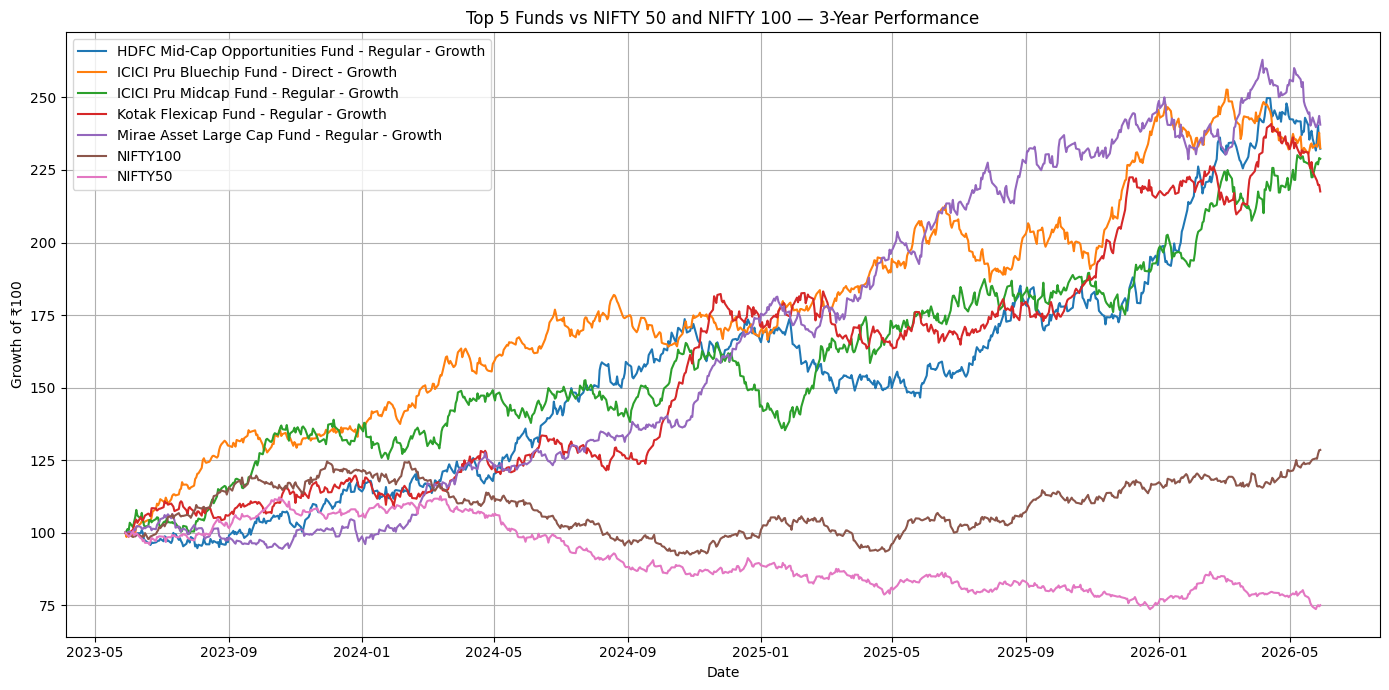

benchmark_comparison.png saved successfully!


In [52]:
plt.figure(figsize=(14, 7))

for column in comparison_normalized.columns:
    if column in top5["amfi_code"].values:
        fund_name = top5.loc[
            top5["amfi_code"] == column, "scheme_name"
        ].iloc[0]
        plt.plot(
            comparison_normalized.index,
            comparison_normalized[column],
            label=fund_name
        )
    else:
        plt.plot(
            comparison_normalized.index,
            comparison_normalized[column],
            label=column
        )

plt.title("Top 5 Funds vs NIFTY 50 and NIFTY 100 — 3-Year Performance")
plt.xlabel("Date")
plt.ylabel("Growth of ₹100")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("benchmark_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print("benchmark_comparison.png saved successfully!")

In [53]:
# Prepare NIFTY 100 returns
nifty100_tracking = benchmark[
    benchmark["index_name"] == "NIFTY100"
][["date", "close_value"]].copy()

nifty100_tracking = nifty100_tracking.sort_values("date")

nifty100_tracking["benchmark_return"] = (
    nifty100_tracking["close_value"].pct_change()
)

# Merge Top 5 fund returns with NIFTY 100 returns
tracking_data = top5_nav[
    ["amfi_code", "date", "daily_return"]
].merge(
    nifty100_tracking[["date", "benchmark_return"]],
    on="date",
    how="inner"
).dropna()

# Calculate tracking error
tracking_results = []

for fund, data in tracking_data.groupby("amfi_code"):
    active_returns = (
        data["daily_return"] - data["benchmark_return"]
    )

    tracking_error = active_returns.std() * np.sqrt(252)

    tracking_results.append({
        "amfi_code": fund,
        "Tracking_Error": tracking_error
    })

tracking_error_table = pd.DataFrame(tracking_results)

# Add fund names
tracking_error_table = tracking_error_table.merge(
    top5[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

tracking_error_table = tracking_error_table[
    ["amfi_code", "scheme_name", "Tracking_Error"]
].sort_values(
    "Tracking_Error"
)

display(tracking_error_table)

,amfi_code,scheme_name,Tracking_Error
1,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.187312
4,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.187867
3,120843,Kotak Flexicap Fund - Regular - Growth,0.206410
0,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.224838
2,120505,ICICI Pru Midcap Fund - Regular - Growth,0.232515


In [54]:
tracking_error_table["Tracking_Error_%"] = (
    tracking_error_table["Tracking_Error"] * 100
).round(2)

display(tracking_error_table)

,amfi_code,scheme_name,Tracking_Error,Tracking_Error_%
1,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.187312,18.73
4,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.187867,18.79
3,120843,Kotak Flexicap Fund - Regular - Growth,0.206410,20.64
0,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.224838,22.48
2,120505,ICICI Pru Midcap Fund - Regular - Growth,0.232515,23.25


In [55]:
tracking_error_table.to_csv(
    "tracking_error.csv",
    index=False
)

print("tracking_error.csv saved successfully!")

tracking_error.csv saved successfully!
